In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor


In [3]:
!pip install catboost xgboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/100.2 MB 3.2 MB/s eta 0:00:31
   ---------------------------------------- 1.0/100.2 MB 2.4 MB/s eta 0:00:41
    --------------------------------------- 1.3/100.2 MB 1.7 MB/s eta 0:00:59
    --------------------------------------- 1.6/100.2 MB 1.8 MB/s eta 0:00:56
    --------------------------------------- 2.1/100.2 MB 1.8 MB/s eta 0:00:54
   - -------------------------------------- 2.6/100.2 MB 1.8 MB/s eta 0:00:54
   - -------------------------------------- 3.1/100.2 MB 2.0 MB/s eta 0:00:50
   - -------------------------------------- 3.7/100.2 MB 2.1 MB/s eta 0:00:47
   - -------------------------------------- 4.5/100.2 MB 2.2 MB/s eta 0:00:45
   -- ------------------------------------- 5.2/100.2 MB 2.3 MB/s eta 0:00:42
   -- ------------------------------------- 5.8/100.2 MB 2.4 MB/s eta 0:00:40


In [6]:
df = pd.read_csv("data/StudentsPerformance.csv")

In [7]:
df.head(2)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


In [9]:
x = df.drop(["math score"], axis = 1)

y= df["math score"]

x.shape, y.shape

((1000, 7), (1000,))

In [10]:
type(x)

pandas.core.frame.DataFrame

In [14]:
numerical_features = x.select_dtypes(exclude = "object").columns
numerical_features

Index(['reading score', 'writing score'], dtype='object')

In [15]:
categorical_features = x.select_dtypes(include = "object").columns
categorical_features

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course'],
      dtype='object')

In [16]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    transformers= [
        ("StandardScaler", numeric_transformer, numerical_features),
        ("OneHotEncoder", categorical_transformer, categorical_features)
    ]
)

In [17]:
x = preprocessor.fit_transform(x)

In [ ]:
x.shape

(1000, 19)

In [36]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = .2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 19), (200, 19), (800,), (200,))

In [37]:
from sklearn.metrics import mean_absolute_error
import math
def evaluate_model(actual, predicted):
    mse = mean_squared_error(actual, predicted)
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)
    rmse = math.sqrt(mse)
    return mae, mse, r2, rmse

In [42]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "KNeighborsRegressor": KNeighborsRegressor(),
    "DecisionTreeRegressor": DecisionTreeRegressor(),
    "RandomForestRegressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoostRegressor": CatBoostRegressor(),
    "AdaBoostRegressor": AdaBoostRegressor()
}

model_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    trainin_mae, trainin_mse, trainin_r2, trainin_rmse = evaluate_model(y_train, y_train_pred)
    testin_mae, testin_mse, testin_r2, testin_rmse = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])

    model_list.append(list(models.keys())[i])

    print("Model Performance for Training Set")
    print("-- Mean Absolute Error: {:.4f}".format(trainin_mae))
    print("-- Mean Squared Error: {:.4f}".format(trainin_mse))
    print("-- R2 Score: {:.4f}".format(trainin_r2))
    print("-- Root Mean Squared Error: {:.4f}".format(trainin_rmse))

    print("\n------------------------------------------")

    print("Model Performance for Testing Set")
    print("-- Mean Absolute Error: {:.4f}".format(testin_mae))
    print("-- Mean Squared Error: {:.4f}".format(testin_mse))
    print("-- R2 Score: {:.4f}".format(testin_r2))
    print("-- Root Mean Squared Error: {:.4f}".format(testin_rmse))

    r2_list.append(testin_r2)

    print("="*35)
    print("\n")


Linear Regression
Model Performance for Training Set
-- Mean Absolute Error: 4.1663
-- Mean Squared Error: 27.3696
-- R2 Score: 0.8827
-- Root Mean Squared Error: 5.2316

------------------------------------------
Model Performance for Testing Set
-- Mean Absolute Error: 4.5714
-- Mean Squared Error: 32.5687
-- R2 Score: 0.8471
-- Root Mean Squared Error: 5.7069


Lasso
Model Performance for Training Set
-- Mean Absolute Error: 5.1347
-- Mean Squared Error: 42.2205
-- R2 Score: 0.8191
-- Root Mean Squared Error: 6.4977

------------------------------------------
Model Performance for Testing Set
-- Mean Absolute Error: 5.1216
-- Mean Squared Error: 42.6283
-- R2 Score: 0.7998
-- Root Mean Squared Error: 6.5290


Ridge
Model Performance for Training Set
-- Mean Absolute Error: 4.1661
-- Mean Squared Error: 27.3721
-- R2 Score: 0.8827
-- Root Mean Squared Error: 5.2318

------------------------------------------
Model Performance for Testing Set
-- Mean Absolute Error: 4.5696
-- Mean Squ

In [43]:
pd.DataFrame(list(zip(model_list, r2_list)), columns = ["Model Name", "R2 Score"]).sort_values(by = ["R2 Score"], ascending= False)

,Model Name,R2 Score
2,Ridge,0.847108
0,Linear Regression,0.847065
5,RandomForestRegressor,0.823696
7,CatBoostRegressor,0.819189
8,AdaBoostRegressor,0.802222
1,Lasso,0.799827
6,XGBRegressor,0.792504
3,KNeighborsRegressor,0.750282
4,DecisionTreeRegressor,0.641255


In [44]:
lin_model = LinearRegression(fit_intercept = True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)
print("Accuracy of the model is %.2f" %score)

Accuracy of the model is 0.85


Text(0, 0.5, 'Predicted')

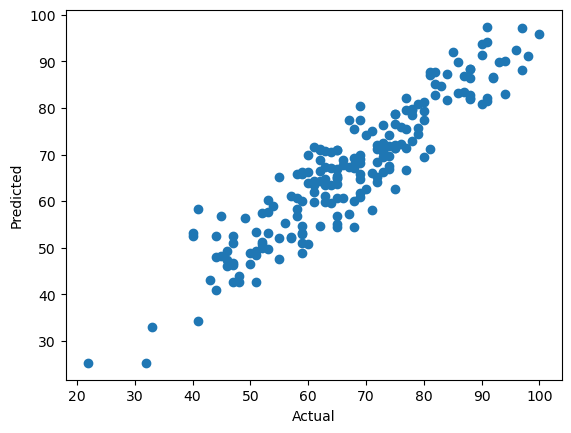

In [45]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

<Axes: xlabel='math score'>

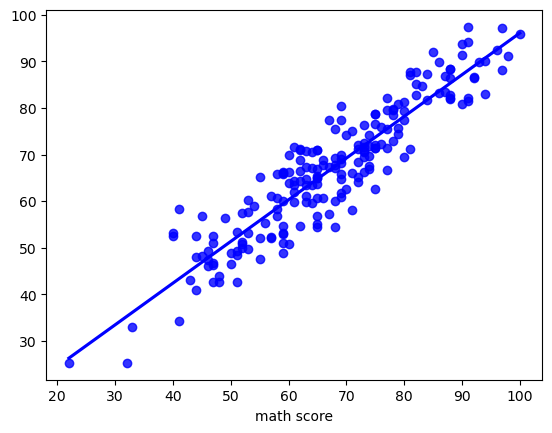

In [46]:
sns.regplot(x = y_test, y = y_pred, ci = None, color = 'b')

In [47]:
pred_df = pd.DataFrame({"Actual Value": y_test, "Predicted Value": y_pred, "Difference": y_test - y_pred})
pred_df

,Actual Value,Predicted Value,Difference
932,61,71.665860,-10.665860
950,94,83.016696,10.983304
248,65,56.750269,8.249731
783,52,50.704446,1.295554
294,78,78.408877,-0.408877
...,...,...,...
264,76,75.866469,0.133531
636,67,67.436790,-0.436790
261,79,80.818034,-1.818034
304,74,69.688316,4.311684
